In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import tensorflow as tf
from math import sqrt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#### Fine-tuning results:

In [2]:
# Best Hyperparameters: {'WINDOW_SIZE': 100, 'NUM_NEURONS': 96, 'DROPOUT_RATE': 0.15000000000000002,
# 'PATIENCE': 9, 'EPOCHS': 160, 'BATCH_SIZE': 128, 'LEARNING_RATE': 0.003435926305551255}

In [3]:
# Define global environment variables

# Train-val-test split (70% training, 20% validation, 10% test)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

# Model hyperparameters (fine-tuned)
WINDOW_SIZE = 100
NUM_NEURONS = 96
DROPOUT_RATE = 0.15
PATIENCE = 9
EPOCHS = 160
BATCH_SIZE = 128
LEARNING_RATE = 0.003435926305551255

## Data analysis

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Update dataset path for Google Drive
data_path = "/content/drive/My Drive/Colab Notebooks/5.0/Bitcoin_data.csv"
data = pd.read_csv(data_path, index_col=0, parse_dates=True)

data

,Open,High,Low,Close,VolumeBTC,VolumeUSD,stoch_k,stoch_d,momentum,macd,macd_signal,atr_short,atr_long,vol_ratio,adx
date,,,,,,,,,,,,,,,
2024-01-01 00:33:00,42367.0,42373.0,42365,42371,0.016585,702.728120,9.166176,6.600790,-94.0,2.261327,24.403575,19.252096,18.831203,102.235086,47.478318
2024-01-01 00:34:00,42357.0,42357.0,42351,42351,0.019690,833.891190,6.163173,7.564574,-121.0,-3.058470,18.911166,19.326887,18.889643,102.314729,44.942988
2024-01-01 00:35:00,42359.0,42359.0,42351,42359,0.031363,1328.501505,3.935135,6.421494,-117.0,-6.553370,13.818259,18.194198,18.345160,99.177099,42.503637
2024-01-01 00:36:00,42368.0,42377.0,42356,42377,0.034081,1444.249689,9.066667,6.388325,-78.0,-7.780961,9.498415,18.474778,18.477902,99.983092,39.498642
2024-01-01 00:37:00,42395.0,42411.0,42392,42403,0.005832,247.290480,22.933333,11.978378,-33.0,-6.580002,6.282732,20.027300,19.254007,104.016271,37.792666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-10 23:39:00,97347.0,97347.0,97339,97339,0.005864,570.787135,57.060236,51.188618,53.0,-10.792340,-12.042076,28.589994,32.832443,87.078484,13.563130
2025-02-10 23:40:00,97339.0,97339.0,97336,97336,0.016011,1558.430149,61.300897,56.935688,-10.0,-10.456826,-11.725026,26.030994,31.340821,83.057793,12.786939
2025-02-10 23:41:00,97340.0,97346.0,97340,97346,0.001320,128.496720,68.840580,62.400571,46.0,-9.277072,-11.235435,24.427895,30.273780,80.689940,12.304698


In [6]:
# data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/5.0/Bitcoin_data.csv",
#                    index_col=0,
#                    parse_dates=True)

In [8]:
data.describe()

,Open,High,Low,Close,VolumeBTC,VolumeUSD,stoch_k,stoch_d,momentum,macd,macd_signal,atr_short,atr_long,vol_ratio,adx
count,565654.000000,565654.000000,565654.000000,565654.000000,565654.000000,5.656540e+05,5.656540e+05,5.656540e+05,565654.000000,565654.000000,565654.000000,565654.000000,565654.000000,565654.000000,565654.000000
mean,69215.992063,69236.049049,69195.680952,69215.996107,1.503927,1.046232e+05,5.091183e+01,5.091171e+01,0.970793,0.679945,0.680227,47.312309,47.312031,98.792006,23.683402
std,17158.321982,17163.133390,17152.812807,17157.806932,4.983205,3.565017e+05,3.156092e+01,3.060139e+01,168.885896,60.402328,56.947867,41.056564,39.100773,10.858473,9.624904
min,38515.000000,38525.000000,38505.000000,38508.000000,0.000000,0.000000e+00,-3.244812e-12,-1.292793e-12,-5704.000000,-1168.966126,-996.770134,0.001141,0.285184,0.400075,5.253474
25%,59822.250000,59843.250000,59804.000000,59824.000000,0.028935,1.897524e+03,2.124506e+01,2.222616e+01,-66.000000,-22.081882,-20.847684,21.950059,22.623782,91.895350,16.620275
50%,65550.000000,65566.000000,65532.000000,65549.000000,0.202128,1.356854e+04,5.131104e+01,5.124156e+01,1.000000,0.627120,0.610386,35.620561,36.159129,98.042547,21.603031
75%,71412.000000,71442.000000,71378.750000,71413.000000,0.865857,5.850943e+04,8.074713e+01,7.978687e+01,69.000000,24.278099,22.871078,59.283965,59.475424,104.930394,28.653812
max,109111.000000,109356.000000,108794.000000,109036.000000,339.941471,3.022984e+07,1.000000e+02,1.000000e+02,3828.000000,1352.084973,1148.450366,934.662473,769.743795,198.612241,86.291479


In [9]:
# The number of missing values
data.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
VolumeBTC,0
VolumeUSD,0
stoch_k,0
stoch_d,0
momentum,0
macd,0


## Data processing

In [10]:
# Train-val-test split
train_ratio = TRAIN_RATIO
val_ratio = VAL_RATIO
test_ratio = TEST_RATIO

# Compute split indices
train_index = int(len(data) * train_ratio)
val_index = train_index + int(len(data) * val_ratio)

# Perform the splits
train_data = data.iloc[:train_index]
val_data = data.iloc[train_index:val_index]
test_data = data.iloc[val_index:]

# Print the shapes to confirm
print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (395957, 15)
Validation shape: (113130, 15)
Test shape: (56567, 15)


In [11]:
# Ensure WINDOW_SIZE does not exceed dataset length
assert WINDOW_SIZE < len(train_data), "WINDOW_SIZE is too large for the dataset size!"

In [12]:
print("Train start:", train_data.index[0], "end:", train_data.index[-1])
print("Val start:", val_data.index[0], "end:", val_data.index[-1])
print("Test start:", test_data.index[0], "end:", test_data.index[-1])

Train start: 2024-01-01 00:33:00 end: 2024-10-10 15:19:00
Val start: 2024-10-10 15:20:00 end: 2024-12-31 19:55:00
Test start: 2024-12-31 19:56:00 end: 2025-02-10 23:43:00


In [13]:
# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(train_data) # Fit only on training data

# Transform train, validation, and test data using the fitted scaler
train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [14]:
# Function to create sequences for time series forecasting
def create_sequences(data_array, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:(i + window_size), :])
        y.append(data_array[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

In [15]:
# Define window size and target column
window_size = WINDOW_SIZE
target_col = 'Close'
target_col_idx = data.columns.get_loc(target_col)

# Create sequences for training, validation and test sets
X_train, y_train = create_sequences(train_scaled, window_size, target_col_idx)
X_val, y_val = create_sequences(val_scaled, window_size, target_col_idx)
X_test, y_test = create_sequences(test_scaled, window_size, target_col_idx)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(395857, 100, 15) (395857,)
(113030, 100, 15) (113030,)
(56467, 100, 15) (56467,)


## Model training (GRU)

In [16]:
# Define GRU model
gru_model = Sequential([
    GRU(NUM_NEURONS, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(DROPOUT_RATE),
    Dense(1) # Predicting the Close price
])
gru_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mean_squared_error')
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 96)                  │          32,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,641 (127.50 KB)

 Trainable params: 32,641 (127.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
history = gru_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 0.0056 - val_loss: 0.0097
Epoch 2/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 2.1319e-04 - val_loss: 0.0098
Epoch 3/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.5438e-04 - val_loss: 0.0064
Epoch 4/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.4549e-04 - val_loss: 0.0027
Epoch 5/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.4260e-04 - val_loss: 0.0105
Epoch 6/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.4143e-04 - val_loss: 0.0017
Epoch 7/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.3408e-04 - val_loss: 0.0016
Epoch 8/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.3343e-04 - val_loss: 0.0025
Epoch 9/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.3303e-04 - val_loss: 0.0012
Epoch 10/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.3198e-04 - val_loss: 8.1921e-04
Epoch 11/160
3093/3093 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - 

In [18]:
# Training and validation loss
history.history.keys()

dict_keys(['loss', 'val_loss'])

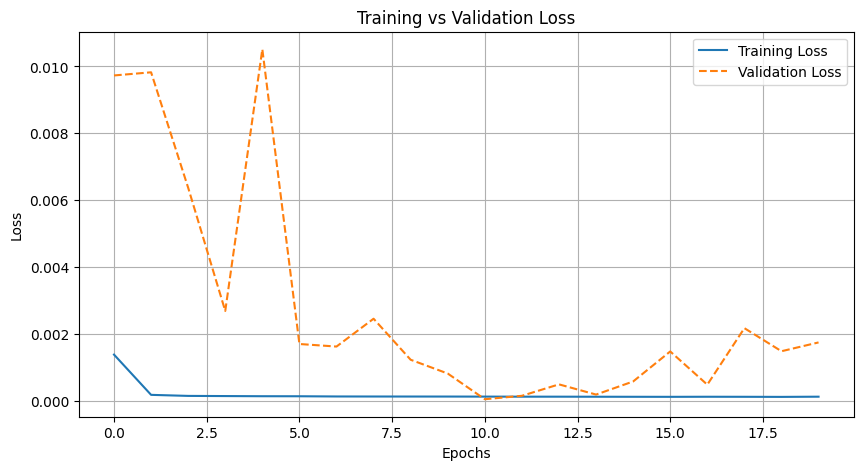

In [19]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### Save the fitted scaler and the model

In [21]:
import joblib

# Save model and scaler in a 'models' directory
gru_model.save("/content/drive/My Drive/Colab Notebooks/5.0/gru_model_5.keras")  # Saves architecture + weights
joblib.dump(scaler, "/content/drive/My Drive/Colab Notebooks/5.0/scaler_5.pkl")  # Saves fitted scaler

['/content/drive/My Drive/Colab Notebooks/5.0/scaler_5.pkl']

## Evaluation

In [22]:
# from keras.models import load_model

# # Load trained model
# gru_model = load_model("/Users/alexzheng/Developer/GitHub/EC331-project/models/gru_model_5.keras")

# # Load trained scaler
# scaler = joblib.load("/Users/alexzheng/Developer/GitHub/EC331-project/models/scaler_5.pkl")

In [23]:
# Crate an inverse function
def inverse_transform_predictions(predicted_scaled, y_actual_scaled, scaler, train_data, target_col_idx):
    """
    Inverse transforms the scaled predictions and actual values back to the original scale.

    Parameters:
    - predicted_scaled: Model predictions in scaled form (shape: (n_samples, 1)).
    - y_actual_scaled: Actual target values in scaled form (shape: (n_samples,)).
    - scaler: The MinMaxScaler fitted on the training data.
    - train_data: The original training dataset (used to get the number of features for inverse transform).
    - target_col_idx: The index of the target column in the dataset.

    Returns:
    - predicted_inverse: Predictions in the original scale.
    - y_actual_inverse: Actual values in the original scale.
    """

    # Create full arrays with the same shape as train_data for inverse transformation
    predicted_full = np.zeros((predicted_scaled.shape[0], train_data.shape[1]))
    y_actual_full = np.zeros((y_actual_scaled.shape[0], train_data.shape[1]))

    # Fill only the target column ('Close' price)
    predicted_full[:, target_col_idx] = predicted_scaled[:, 0]  # Ensure correct shape
    y_actual_full[:, target_col_idx] = y_actual_scaled  # y_actual is already 1D

    # Apply inverse transform
    predicted_inverse = scaler.inverse_transform(predicted_full)[:, target_col_idx]
    y_actual_inverse = scaler.inverse_transform(y_actual_full)[:, target_col_idx]

    return predicted_inverse, y_actual_inverse

### Training set evaluation

In [24]:
# Get inverse transformed predictions and actual values
predicted_train_inverse, y_train_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_train),
    y_actual_scaled=y_train,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

12371/12371 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step


In [25]:
# Compute error metrics for the training set
mae_train = mean_absolute_error(y_train_inverse, predicted_train_inverse)
rmse_train = sqrt(mean_squared_error(y_train_inverse, predicted_train_inverse))
mape_train = np.mean(np.abs((y_train_inverse - predicted_train_inverse) / y_train_inverse)) * 100

print(f"Train MAE: {mae_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train MAPE: {mape_train:.2f}%")

Train MAE: 91.1099
Train RMSE: 107.9525
Train MAPE: 0.15%


### Validation set evaluation

In [26]:
# Get inverse transformed predictions and actual values
predicted_val_inverse, y_val_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_val),
    y_actual_scaled=y_val,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

3533/3533 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [27]:
# Compute error metrics for the val set
mae_val = mean_absolute_error(y_val_inverse, predicted_val_inverse)
rmse_val = sqrt(mean_squared_error(y_val_inverse, predicted_val_inverse))
mape_val = np.mean(np.abs((y_val_inverse - predicted_val_inverse) / y_val_inverse)) * 100

print(f"Validation MAE: {mae_val:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAPE: {mape_val:.2f}%")

Validation MAE: 217.4724
Validation RMSE: 252.6297
Validation MAPE: 0.25%


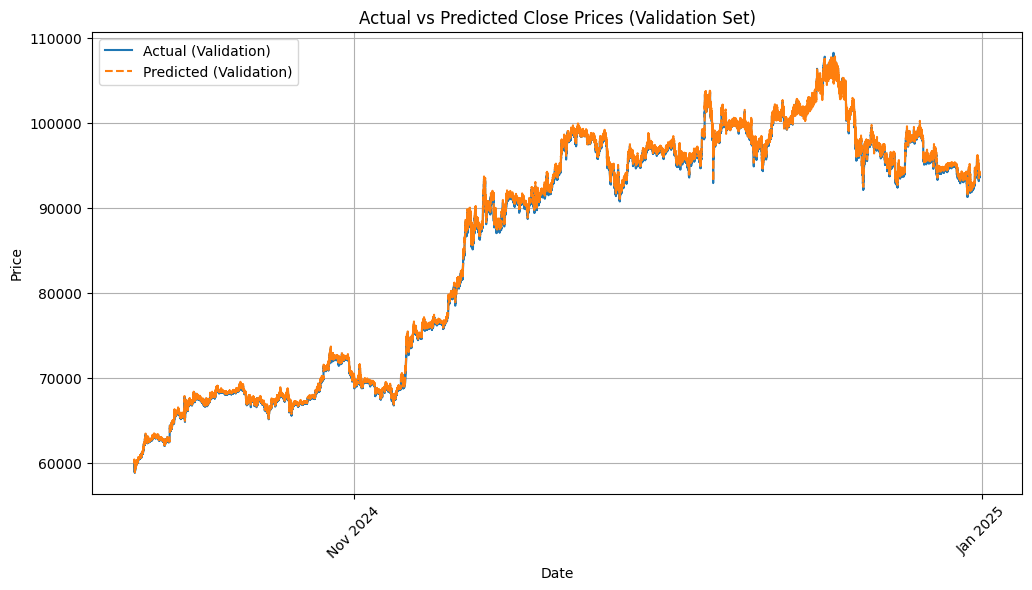

In [28]:
# Extract date index for plotting
date_index = val_data.index[window_size:]  # Align with sequence offset

# Plot actual vs predicted Close prices for validation set
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='Predicted (Validation)', linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Benchmark against a Naïve Forecast

In [29]:
val_data.head()

,Open,High,Low,Close,VolumeBTC,VolumeUSD,stoch_k,stoch_d,momentum,macd,macd_signal,atr_short,atr_long,vol_ratio,adx
date,,,,,,,,,,,,,,,
2024-10-10 15:20:00,60620.0,60620.0,60603,60603,0.009907,600.363620,30.296385,36.902972,-33.0,12.721192,17.575676,41.475128,45.523461,91.107150,14.177121
2024-10-10 15:21:00,60592.0,60657.0,60592,60622,0.873445,52949.954904,38.417065,34.518430,-30.0,11.911447,16.442831,43.827615,46.497288,94.258433,13.382890
2024-10-10 15:22:00,60612.0,60613.0,60512,60522,0.210738,12754.299761,23.733365,30.815605,-143.0,3.164081,13.787081,50.444854,49.672424,101.555048,13.494233
2024-10-10 15:23:00,60454.0,60502.0,60454,60502,0.218499,13219.597457,21.625240,27.925223,-173.0,-5.320768,9.965511,52.200368,50.588803,103.185618,14.326702
2024-10-10 15:24:00,60498.0,60507.0,60494,60503,0.003171,191.880424,14.854087,20.070897,-180.0,-11.828034,5.606802,48.280332,48.709362,99.119203,15.001218


In [30]:
actual_val = val_data['Close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_val.iloc[window_size - 1:-1].values
actual_val_values = actual_val.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_val_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_val_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_val_values - naive_predictions) / actual_val_values)) * 100

print(f"Validation Naive MAE: {mae_naive:.4f}")
print(f"Validation Naive RMSE: {rmse_naive:.4f}")
print(f"Validation Naive MAPE: {mape_naive:.2f}%")

Validation Naive MAE: 40.1807
Validation Naive RMSE: 64.0811
Validation Naive MAPE: 0.05%


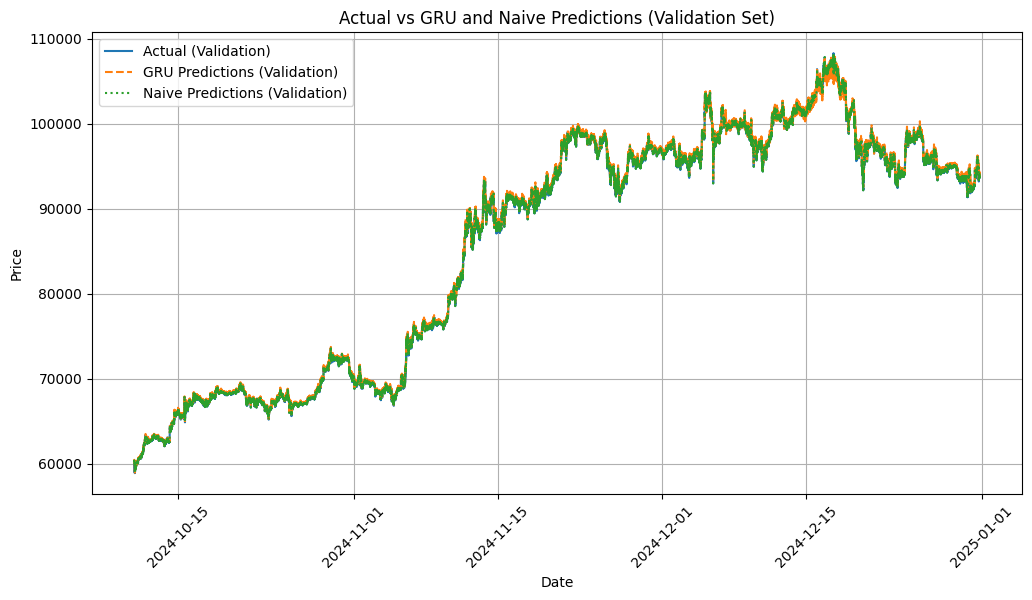

In [31]:
# Prepare a date index for plotting (adjusting for the sequence offset)
date_index = val_data.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(date_index, y_val_inverse, label='Actual (Validation)')
plt.plot(date_index, predicted_val_inverse, label='GRU Predictions (Validation)', linestyle='dashed')
plt.plot(date_index, naive_predictions, label='Naive Predictions (Validation)', linestyle='dotted')
plt.title('Actual vs GRU and Naive Predictions (Validation Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Test set evaluation

In [32]:
# Get inverse transformed predictions and actual values
predicted_test_inverse, y_test_inverse = inverse_transform_predictions(
    predicted_scaled=gru_model.predict(X_test),
    y_actual_scaled=y_test,
    scaler=scaler,
    train_data=train_data,
    target_col_idx=target_col_idx
)

1765/1765 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [33]:
# Compute error metrics for the test set
mae_test = mean_absolute_error(y_test_inverse, predicted_test_inverse)
rmse_test = sqrt(mean_squared_error(y_test_inverse, predicted_test_inverse))
mape_test = np.mean(np.abs((y_test_inverse - predicted_test_inverse) / y_test_inverse)) * 100

print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAPE: {mape_test:.2f}%")

Test MAE: 251.0126
Test RMSE: 299.1108
Test MAPE: 0.25%


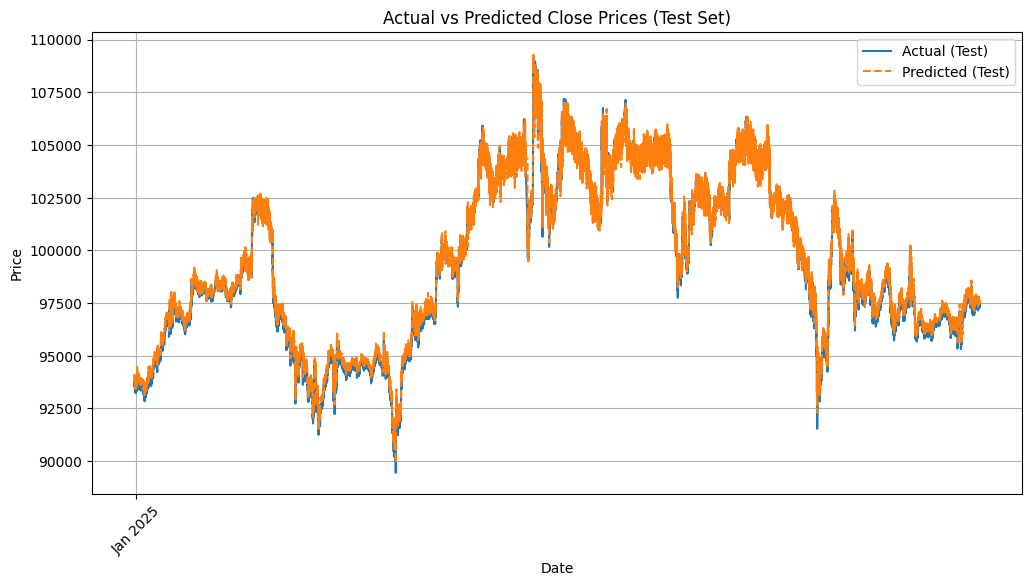

In [34]:
# Extract date index for plotting
date_index = test_data.index[window_size:]  # Align with sequence offset

# Plot actual vs predicted Close prices for test set
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_inverse, label='Actual (Test)')
plt.plot(date_index, predicted_test_inverse, label='Predicted (Test)', linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

#### Against the benchmark

In [35]:
test_data.head()

,Open,High,Low,Close,VolumeBTC,VolumeUSD,stoch_k,stoch_d,momentum,macd,macd_signal,atr_short,atr_long,vol_ratio,adx
date,,,,,,,,,,,,,,,
2024-12-31 19:56:00,93950.0,93950.0,93950,93950,0.008810,827.699500,84.237726,85.759403,239.0,33.249476,9.855354,46.490553,46.070527,100.911702,27.544747
2024-12-31 19:57:00,93955.0,94003.0,93955,94003,0.021880,2056.780940,90.180879,85.874246,292.0,40.485730,15.981429,47.141497,46.417001,101.560844,28.034239
2024-12-31 19:58:00,94011.0,94011.0,93969,93969,0.090054,8462.330371,92.237929,88.885511,176.0,42.981533,21.381450,46.627348,46.196151,100.933405,28.573741
2024-12-31 19:59:00,93976.0,94009.0,93976,94008,0.000433,40.730846,95.091503,92.503437,116.0,47.558227,26.616805,45.964613,45.886343,100.170573,29.074708
2024-12-31 20:00:00,94025.0,94025.0,93987,94025,0.546000,51337.637777,95.091503,94.140312,132.0,51.958108,31.685066,45.168152,45.492026,99.288064,29.725606


In [36]:
actual_test = test_data['Close']

# Since sequences start from window_size, align the naive forecast accordingly:
naive_predictions = actual_test.iloc[window_size - 1:-1].values
actual_test_values = actual_test.iloc[window_size:].values

# Compute error metrics for the naive baseline
mae_naive = mean_absolute_error(actual_test_values, naive_predictions)
rmse_naive = sqrt(mean_squared_error(actual_test_values, naive_predictions))
mape_naive = np.mean(np.abs((actual_test_values - naive_predictions) / actual_test_values)) * 100

print(f"Test Naive MAE: {mae_naive:.4f}")
print(f"Test Naive RMSE: {rmse_naive:.4f}")
print(f"Test Naive MAPE: {mape_naive:.2f}%")

Test Naive MAE: 48.4639
Test Naive RMSE: 80.8601
Test Naive MAPE: 0.05%


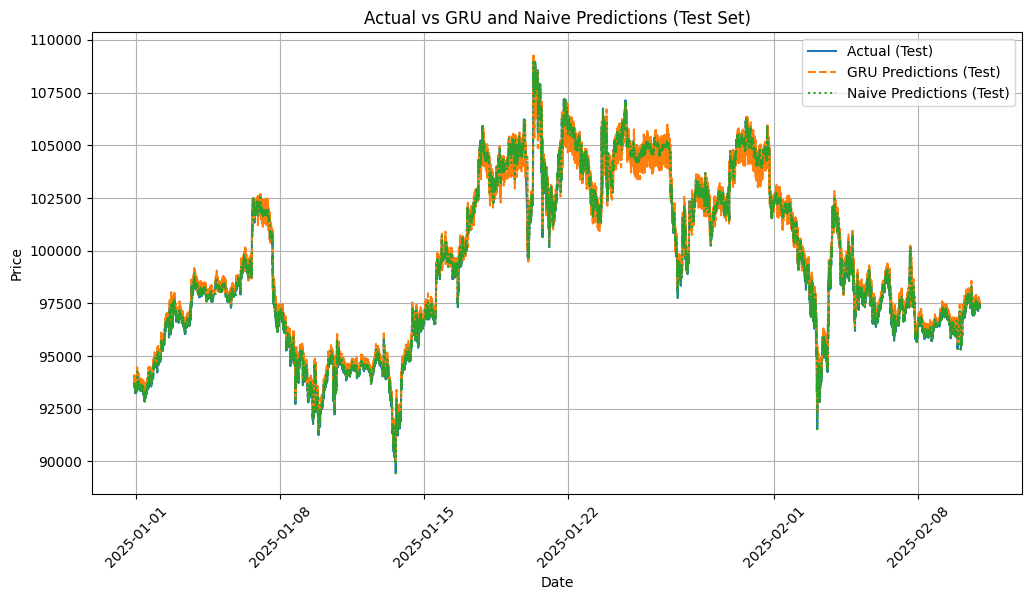

In [37]:
# Prepare a date index for plotting (adjusting for the sequence offset)
date_index = test_data.index[window_size:]

plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_inverse, label='Actual (Test)')
plt.plot(date_index, predicted_test_inverse, label='GRU Predictions (Test)', linestyle='dashed')
plt.plot(date_index, naive_predictions, label='Naive Predictions (Test)', linestyle='dotted')
plt.title('Actual vs GRU and Naive Predictions (Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()